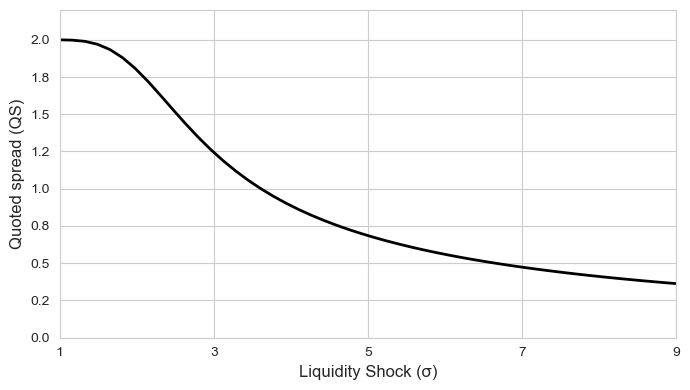

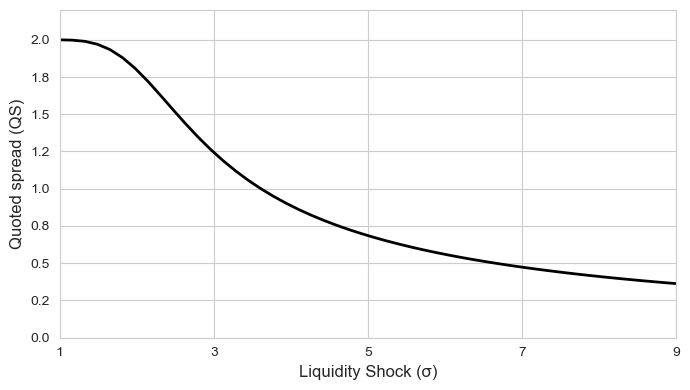

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
from scipy.optimize import fsolve

def glosten_milgrom_price(sigma, delta_v, mu=0.5, v_h=4, v_l=0):
    """
    Calculate Glosten-Milgrom competitive price using equation (6)
    a* = E_μ(v̄) + Δ_D * (1-μ)μΔ_D(a*) / E_μ(V(a*, v̄^C))
    """
    expected_v = mu * v_h + (1 - mu) * v_l  # E_μ(v̄) = 2
    
    def demand_function(price, asset_value, sigma):
        """D(a, v) = P(v̄^C ≥ a | v̄ = v) = 1 - Φ((a - v)/σ)"""
        return 1 - norm.cdf((price - asset_value) / sigma)
    
    def delta_d_function(price, sigma):
        """Δ_D(a) = D(a, v_H) - D(a, v_L)"""
        return demand_function(price, v_h, sigma) - demand_function(price, v_l, sigma)
    
    def expected_trading_volume(price, sigma, mu):
        """E_μ(V(a, v̄^C)) = μD(a, v_H) + (1-μ)D(a, v_L)"""
        return mu * demand_function(price, v_h, sigma) + (1 - mu) * demand_function(price, v_l, sigma)
    
    def gm_equation(price):
        """Equation (6): a* = E_μ(v̄) + Δ_v * (1-μ)μΔ_D(a*) / E_μ(V(a*, v̄^C))"""
        delta_d = delta_d_function(price, sigma)
        expected_vol = expected_trading_volume(price, sigma, mu)
        
        if expected_vol <= 1e-10:  # Avoid division by zero
            return price - expected_v
            
        adverse_selection_cost = delta_v * (1 - mu) * mu * delta_d / expected_vol
        return price - expected_v - adverse_selection_cost
    
    # Solve for equilibrium price
    try:
        price_solution = fsolve(gm_equation, expected_v + 0.5)[0]
        return max(price_solution, expected_v)  # Price should be at least expected value
    except:
        return expected_v

def create_glosten_milgrom_figure():
    """Create figure using actual G-M equations"""
    sns.set_style("whitegrid")
    fig, ax = plt.subplots(figsize=(7,4))
    
    # Parameters
    mu = 0.5
    v_h = 4
    v_l = 0
    expected_v = mu * v_h + (1 - mu) * v_l  # E[v] = 2.0
    
    # LEFT PANEL: Quoted Spread vs Liquidity Shock (σ)
    sigma_range = np.linspace(1, 9, 50)  # Fewer points for faster computation
    qs_sigma = []
    
    for sigma in sigma_range:
        price = glosten_milgrom_price(sigma=sigma, delta_v=4, mu=mu, v_h=v_h, v_l=v_l)
        quoted_spread = price - expected_v
        qs_sigma.append(quoted_spread)
        
    ax.plot(sigma_range, qs_sigma, 'k-', linewidth=2)
    ax.set_xlabel('Liquidity Shock (σ)', fontsize=12)
    ax.set_ylabel('Quoted spread (QS)', fontsize=12)
    ax.set_xlim(1, 9)
    ax.set_xticks([1,3,5,7,9])
    ax.set_ylim(0, 2.2)
    ax.yaxis.set_major_formatter(plt.FormatStrFormatter('%.1f'))
    ax.grid(True)
    
    # # RIGHT PANEL: Quoted Spread vs Asset Volatility (Δv)
    # delta_v_range = np.linspace(0, 8, 50)
    # qs_delta_v = []
    
    # for delta_v in delta_v_range:
    #     if delta_v == 0:
    #         qs_delta_v.append(0)  # No adverse selection when Δv = 0
    #     else:
    #         # Update v_h and v_l to maintain E[v] = 2 while varying Δv
    #         v_h_temp = expected_v + delta_v/2
    #         v_l_temp = expected_v - delta_v/2
    #         price = glosten_milgrom_price(sigma=5, delta_v=delta_v, mu=mu, 
    #                                     v_h=v_h_temp, v_l=v_l_temp)
    #         quoted_spread = price - expected_v
    #         qs_delta_v.append(quoted_spread)
    
    # ax2.plot(delta_v_range, qs_delta_v, 'k-', linewidth=2)
    # ax2.set_xlabel('Asset Volatility (Δv)', fontsize=12) 
    # ax2.set_ylabel('Quoted spread (QS)', fontsize=12)
    # ax2.set_xlim(0, 8)
    # ax2.set_ylim(0, 3.2)
    # ax2.yaxis.set_major_formatter(plt.FormatStrFormatter('%.1f'))
    # ax2.grid(False)
    
    plt.tight_layout()
    plt.savefig(f'C:/Users/adigo/Desktop/Thesis folder/Masters_Thesis/gm_fig.pdf',
                bbox_inches='tight', dpi=300)
    plt.show()
    
    return fig

create_glosten_milgrom_figure()
